In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load your Practice Dataset
df = pd.read_excel('Practice_Dataset.xlsx')

# How many missing values per column?
print(df.isnull().sum())
print()
print(f'Total missing: {df.isnull().sum().sum()}')
print(f'Dataset shape: {df.shape}')

# What percentage of each column is missing?
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
print('\nMissing percentage per column:')
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

badge_number     0
name             0
position         0
work_date        0
in_time         35
out_time        35
punch_count      0
status           0
dtype: int64

Total missing: 70
Dataset shape: (360, 8)

Missing percentage per column:
in_time     9.72
out_time    9.72
dtype: float64


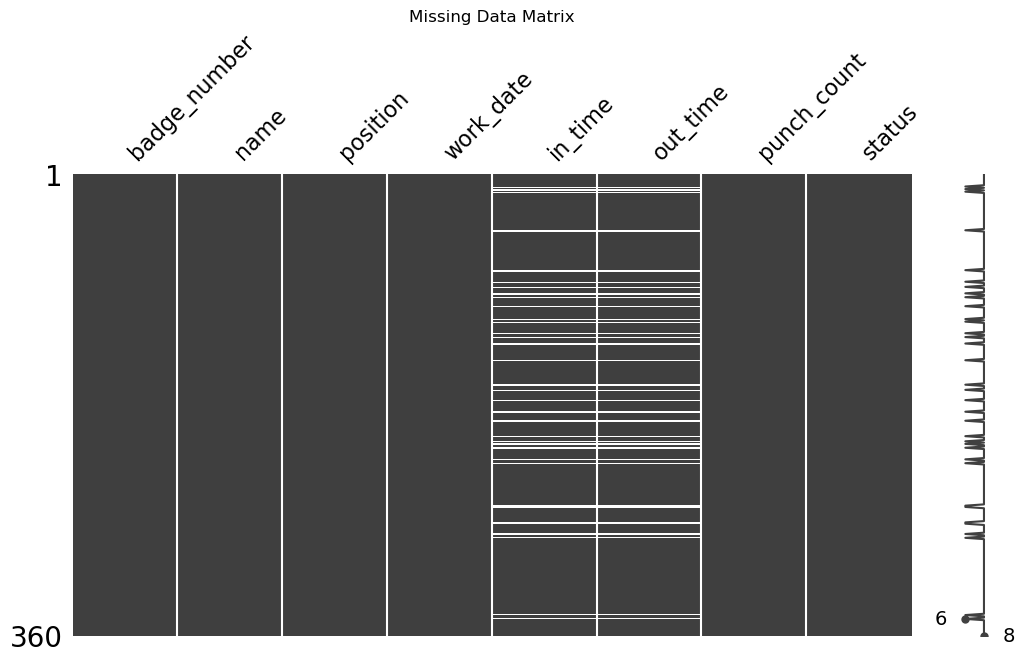

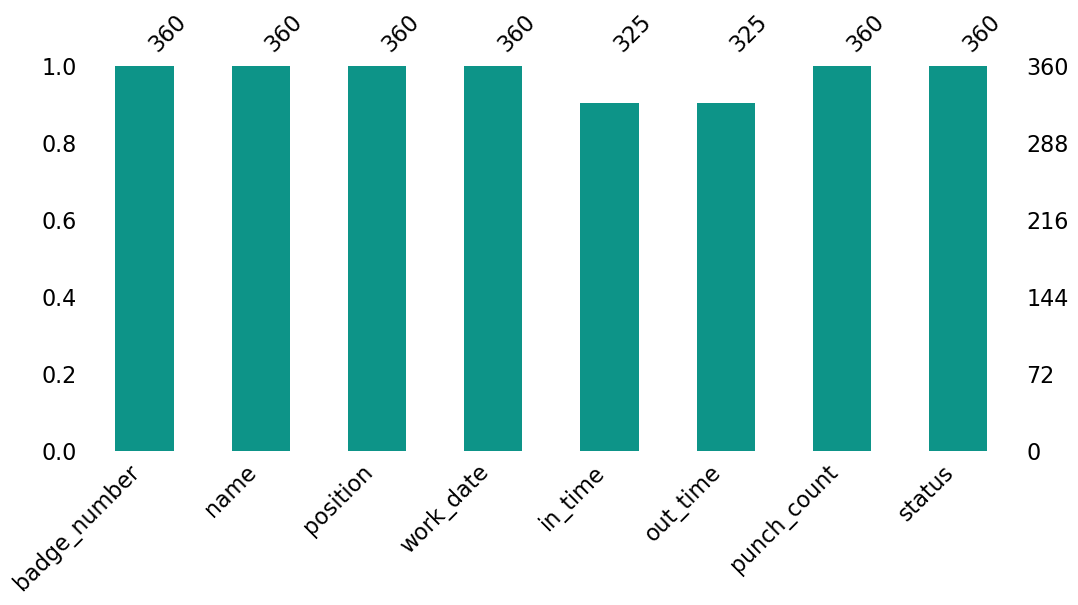

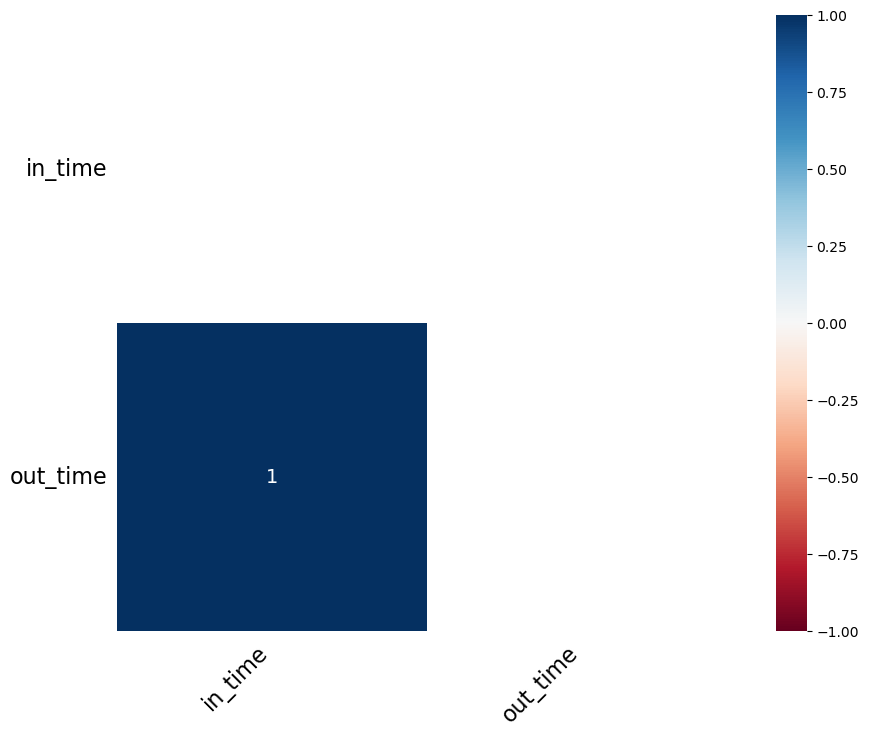

In [5]:
import missingno as msno

# Matrix view — white lines = missing values
msno.matrix(df, figsize=(12, 6))
plt.title('Missing Data Matrix')
plt.savefig('missing_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar chart — shows completeness per column
msno.bar(df, figsize=(12, 5), color='#0D9488')
plt.savefig('missing_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Heatmap — shows correlation between missing values
# If two columns are often missing together, they may be related
msno.heatmap(df, figsize=(10, 8))
plt.savefig('missing_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# When to drop:
# - Very few rows are affected (< 5%)
# - The missing data is random (MCAR)
# - A column is mostly empty (> 50% missing)

df_copy = df.copy()  # Always work on a copy!

# Drop rows where ANY value is missing
df_dropped_any = df_copy.dropna()
print(f'Before: {len(df_copy)} rows -> After dropna(): {len(df_dropped_any)} rows')

# Drop rows where a SPECIFIC column is missing
df_dropped_col = df_copy.dropna(subset=['status'])
print(f'After dropping missing status: {len(df_dropped_col)} rows')

# Drop columns that are mostly empty (> 50% missing)
threshold = len(df_copy) * 0.5
df_dropped_cols = df_copy.dropna(axis=1, thresh=int(threshold))
print(f'Columns before: {df_copy.shape[1]} -> After: {df_dropped_cols.shape[1]}')

Before: 360 rows -> After dropna(): 325 rows
After dropping missing status: 360 rows
Columns before: 8 -> After: 8


In [7]:
df_fill = df.copy()

# Fill numeric columns with the MEDIAN (robust to outliers)
numeric_cols = df_fill.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_fill[col].isnull().sum() > 0:
        median_val = df_fill[col].median()
        df_fill[col] = df_fill[col].fillna(median_val)
        print(f'Filled {col} with median: {median_val}')

# Fill categorical columns with the MODE (most frequent value)
cat_cols = df_fill.select_dtypes(include='object').columns
for col in cat_cols:
    if df_fill[col].isnull().sum() > 0:
        mode_val = df_fill[col].mode()[0]
        df_fill[col] = df_fill[col].fillna(mode_val)
        print(f'Filled {col} with mode: {mode_val}')

# Forward fill — use previous row's value (good for time series)
# df_fill['column'].fillna(method='ffill', inplace=True)
# Backward fill — use next row's value
# df_fill['column'].fillna(method='bfill', inplace=True)

# Verify: no more missing values
print(f'\nRemaining missing values: {df_fill.isnull().sum().sum()}')

Filled in_time with mode: 06:19
Filled out_time with mode: 16:38

Remaining missing values: 0


In [9]:
# Create a cleaning log — this is CRITICAL for reproducibility
cleaning_log = []

for col in df.columns:
    n_missing = df[col].isnull().sum()
    if n_missing > 0:
        pct = round(n_missing / len(df) * 100, 1)
        if col in numeric_cols:
            action = f'Filled with median ({df_fill[col].median():.2f})'
            reason = 'Median chosen over mean because of outliers/skew'
        else:
            action = f"Filled with mode ('{df_fill[col].mode()[0]}')"
            reason = 'Mode used for categorical data'
        cleaning_log.append({
            'column': col,
            'issue': f'{n_missing} missing values ({pct}%)',
            'action': action,
            'reason': reason
        })

log_df = pd.DataFrame(cleaning_log)
print(log_df)
log_df.to_csv('cleaning_log.csv', index=False)

     column                     issue                      action  \
0   in_time  35 missing values (9.7%)  Filled with mode ('06:19')   
1  out_time  35 missing values (9.7%)  Filled with mode ('16:38')   

                           reason  
0  Mode used for categorical data  
1  Mode used for categorical data  
